In [9]:
from IPython.display import Image
import sys
import os
import pandas as pd
import numpy as np
import glob
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
plt.rc('text', usetex=False)

# sys.path.append('C:/Users/lego_/Downloads/Research Files/analysis_ver1.0_NP/analysis_ver1.0_NP')
sys.path.append('/Users/caaponte/Documents/1.Research/A-R_Research/Research/simulations/python_code/polymer_simulation_scripts/analysis_ver1.0')

# sys.path.append('C:/Users/lego_/Downloads/Research Files/analysis_ver1.0_NP/analysis_ver1.0_NP')

from postproc_plots import plot_csv_log_lin
from postproc_plots import plot_csv_log_log
from postproc_plots import plot_csv_log_log_wlim
from postproc_plots import plot_csv_lin_lin

from postproc_plots import plot_csv_lin_lin_wlim
from postproc_plots import plot_csv_lin_log_wlim
from postproc_plots import plot_csv_lin_log

import scipy.optimize as optimization
current_dir = sys.path[0]
print(current_dir)

%matplotlib inline

#current_dir = sys.path[0]

import scipy.special as special

/Users/caaponte/Documents/1.Research/A-R_Research/Research_Group/Mentees/1.SBU/undergraduate/3.Evangelista,J./2.Jack_Drive_Folder/Articles


In [10]:
#All the articles that data was extracted from


# Article_home= "C:/Users/lego_/Downloads/Research Files/Articles"
Article_home= current_dir

Article_1=['/T. N. Phung, Ph.D. thesis, California Institute of Technology, 1993/'
          ]
Article_2=['/I. M. Krieger, Adv. Colloid Interface Sci. 3, 111 (1972)/'
          ]
Article_3=['/J. C van der Werff and C. G. de Kreuif, J. Rheol. 33, 3462 1989/'
          ]
Article_4=['/Cheng SW, Xie SJ, Carrillo JMY, et al. ACS Nano. 2017 [Article 2]/'
          ]

Article_Theory=['/Brady Article/'
               ]
data_directories_1 = [Article_home + item for item in Article_1]
data_directories_2 = [Article_home + item for item in Article_2]
data_directories_3 = [Article_home + item for item in Article_3]
data_directories_4 = [Article_home + item for item in Article_4]

data_directories_theory = [Article_home + item for item in Article_Theory]

#Phung data
#T. N. Phung, Ph.D. thesis, California Institute of Technology, 1993.
data_A1G1=[np.genfromtxt(Article_1_item+"SP_P0.01.csv" , delimiter=',', skip_header=6) for Article_1_item in data_directories_1]

data_A1=data_A1G1


#Krieger data
#I. M. Krieger, Adv. Colloid Interface Sci. 3, 111 (1972).
data_A2G1=[np.genfromtxt(Article_2_item+"Low_Shear_Viscosity.csv" , delimiter=',', skip_header=6) for Article_2_item in data_directories_2]

data_A2=data_A2G1

#Van der Werff Full data
#J. C. van der Werff and C. G. de Kruif, 1. Rheol. 33, 4221 (1989).
data_A3G1=[np.genfromtxt(Article_3_item+"SP23_28nm.csv" , delimiter=',', skip_header=6) for Article_3_item in data_directories_3]
data_A3G2=[np.genfromtxt(Article_3_item+"SSF1_46nm.csv" , delimiter=',', skip_header=6) for Article_3_item in data_directories_3]
data_A3G3=[np.genfromtxt(Article_3_item+"SJ18_76nm.csv" , delimiter=',', skip_header=6) for Article_3_item in data_directories_3]
data_A3G4=[np.genfromtxt(Article_3_item+"SJ14_110nm.csv" , delimiter=',', skip_header=6) for Article_3_item in data_directories_3]

data_A3=data_A3G1+data_A3G2+data_A3G3+data_A3G4

#Cheng data
#Cheng, Shiwang, et al. “Big Effect of Small Nanoparticles: A Shift in Paradigm for Polymer Nanocomposites.” ACS Nano., vol. 11, no. 1, 2017, pp. 752–59, https://doi.org/10.1021/acsnano.6b07172.
data_A4G1=[np.genfromtxt(Article_4_item+"Loading % vs. Viscosity.csv" , delimiter=',', skip_header=17) for Article_4_item in data_directories_4]

data_A4=data_A4G1

#Theoretical Prediction
#Brady, John F. “, 1757 (1994)].” The Journal of Chemical Physics., vol. 101, no. 2, 1994, pp. 1758–1758, https://doi.org/10.1063/1.467737.
data_theory1=[np.genfromtxt(Article_theory_item+"Theoretical Prediction.csv" , delimiter=',', skip_header=6) for Article_theory_item in data_directories_theory]
data_theory2=[np.genfromtxt(Article_theory_item+"Theoretical Prediction_Dashed.csv" , delimiter=',', skip_header=6) for Article_theory_item in data_directories_theory]

data_T=data_theory1+data_theory2


# Relative viscosity vs. mass fraction

Article_5=['/Nanoscale effects. MichaelE. Mackay. 2003/'
          ]
Article_6=['/N-Dependence in the viscosity. Tao Chen, Nat Commun (2019)/'
          ]

data_directories_5 = [Article_home + item for item in Article_5]
data_directories_6 = [Article_home + item for item in Article_6]

#Nanoscale effects data
#Mackay, Michael E., et al. “Nanoscale Effects Leading to Non-Einstein-like Decrease in Viscosity.” Nature Materials., vol. 2, no. 11, 2003, pp. 762–66, https://doi.org/10.1038/nmat999.
data_A5G1=[np.genfromtxt(Article_5_item+"Nanoscale effects. Michael E. Mackay. (75k linear PS).csv" , delimiter=',', skip_header=6) for Article_5_item in data_directories_5]
data_A5G2=[np.genfromtxt(Article_5_item+"Nanoscale effects. Michael E. Mackay. (393k linear PS).csv" , delimiter=',', skip_header=6) for Article_5_item in data_directories_5]

data_A5=data_A5G1+data_A5G2

#N-Dependence data
#Chen, Tao, et al. “An Unexpected N-Dependence in the Viscosity Reduction in All-Polymer Nanocomposite.” Nature Communications., vol. 10, no. 1, 2019, https://doi.org/10.1038/s41467-019-13410-z.
data_A6=[np.genfromtxt(Article_6_item+"Relative Viscosity vs Mass ratio.csv" , delimiter=',', skip_header=12) for Article_6_item in data_directories_6]


#Combined Mass fraction data
massf_data=data_A5+data_A6

# Article_7=['/Chatzaki, rheological response of polymer nanocomposites 2023/'
#           ]

# data_directories_7 = [Article_home + item for item in Article_7]

# data_A7G1_1=[np.genfromtxt(Article_7_item+"PEO3.35k,NP7.csv",delimiter=',',skip_header=6) for Article_7_item in data_directories_7]
# data_A7G1_2=[np.genfromtxt(Article_7_item+"PEO35k,NP7.csv",delimiter=',',skip_header=6) for Article_7_item in data_directories_7]
# data_A7G1_3=[np.genfromtxt(Article_7_item+"PEO100k,NP7.csv",delimiter=',',skip_header=6) for Article_7_item in data_directories_7]
# data_A7G1_4=[np.genfromtxt(Article_7_item+"PEO300k,NP7.csv",delimiter=',',skip_header=6) for Article_7_item in data_directories_7]
# data_A7G2_1=[np.genfromtxt(Article_7_item+"PEO3.35k,NP67.csv",delimiter=',',skip_header=6) for Article_7_item in data_directories_7]
# data_A7G2_2=[np.genfromtxt(Article_7_item+"PEO8k,NP67.csv",delimiter=',',skip_header=6) for Article_7_item in data_directories_7]
# data_A7G2_3=[np.genfromtxt(Article_7_item+"PEO35k,NP67.csv",delimiter=',',skip_header=6) for Article_7_item in data_directories_7]
# data_A7G2_4=[np.genfromtxt(Article_7_item+"PEO100k,NP67.csv",delimiter=',',skip_header=6) for Article_7_item in data_directories_7]
# data_A7G2_5=[np.genfromtxt(Article_7_item+"PEO300k,NP67.csv",delimiter=',',skip_header=6) for Article_7_item in data_directories_7]

# data_A7=data_A7G1_1+data_A7G1_2+data_A7G1_3+data_A7G1_4+data_A7G2_1+data_A7G2_2+data_A7G2_3+data_A7G2_4+data_A7G2_5



#ALL DATA for relative viscosity vs. volume fraction
data_from_all=data_A1+data_A2+data_A3+data_A4+data_T+data_A5+data_A6 #+data_A7
#data_from_all=data_A4



#Citations
#T. N. Phung, Ph.D. thesis, California Institute of Technology, 1993.
#I. M. Krieger, Adv. Colloid Interface Sci. 3, 111 (1972).
#J. C. van der Werff and C. G. de Kruif, 1. Rheol. 33, 4221 (1989).
#Cheng, Shiwang, et al. “Big Effect of Small Nanoparticles: A Shift in Paradigm for Polymer Nanocomposites.” ACS Nano., vol. 11, no. 1, 2017, pp. 752–59, https://doi.org/10.1021/acsnano.6b07172.
#Brady, John F. “, 1757 (1994)].” The Journal of Chemical Physics., vol. 101, no. 2, 1994, pp. 1758–1758, https://doi.org/10.1063/1.467737.
#Mackay, Michael E., et al. “Nanoscale Effects Leading to Non-Einstein-like Decrease in Viscosity.” Nature Materials., vol. 2, no. 11, 2003, pp. 762–66, https://doi.org/10.1038/nmat999.
#Chen, Tao, et al. “An Unexpected N-Dependence in the Viscosity Reduction in All-Polymer Nanocomposite.” Nature Communications., vol. 10, no. 1, 2019, https://doi.org/10.1038/s41467-019-13410-z.


/opt/anaconda3/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


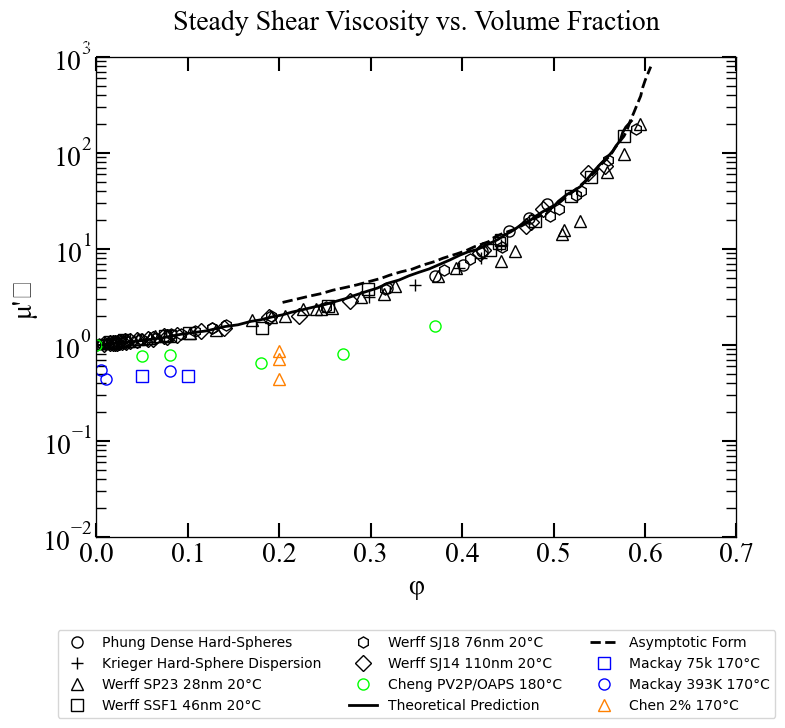

In [11]:
mean_sq_ete_dist_all_names_0 = ["Phung Dense Hard-Spheres","Krieger Hard-Sphere Dispersion","Werff SP23 28nm 20°C","Werff SSF1 46nm 20°C","Werff SJ18 76nm 20°C","Werff SJ14 110nm 20°C","Cheng PV2P/OAPS 180°C", "Theoretical Prediction","Asymptotic Form","Mackay 75k 170°C","Mackay 393K 170°C","Chen 2% 170°C","PEO3.35k/NP7","PEO35k/NP7","PEO100k/NP7","PEO300k/NP7","PEO3.35k/NP67","PEO8k/NP67","PEO35k/NP67","PEO100k/NP67","PEO300k/NP67"]

color_val_0 = [(0,0,0),(0,0,0),(0,0,0),(0,0,0),(0,0,0),(0,0,0),(0,1,0),(0,0,0),(0,0,0),(0,0,1),(0,0,1),(1,0.5,0),(0.52,0.63,0.58),(0,0.28,0.11),(0.15,0.11,0.11),(0.02,0.3,0.33),(0.45,0.45,0.41),(0,0.2,0),(0.76,0.58,0.6),(0.26,0.78,1),(0.15,.17,0.04)]
color_val = color_val_0

style_list_0 = ['o','+','^','s','h','D','o','-','--','s','o','^','^','^','^','^','s','s','s','s','s']
style_list = style_list_0 

linewidth_list = [2 for ii in range(0,len(style_list)) ]
marker_pref = [8,1.0,'none',3]

#plot 1 info
plot_title = 'Steady Shear Viscosity vs. Volume Fraction'
y_axis_title = 'μ\'\N{SUBSCRIPT ZERO}'
x_axis_title = 'φ'
series_title = mean_sq_ete_dist_all_names_0

eye_guides = []
eye_guides_styles = ['k-.','r-.','g-.','b-.']
eye_guides_labels = ['$1/2$ power','$1$ power','$2$ power','$1.25$ power']
xlim=[0,0.7]
ylim=[0.01,1000]


#plot 2 info
plot_title_2 = 'Relative Viscosity vs. Mass fraction'
series_title_2=["Mackay 75k","Mackay 393k","Chen 2%"]
style_list_2=['s','o','^']
x_axis_title_2='Mass fraction'
y_axis_title_2='Viscosity ratio'
color_val_2 = [(0,0,1),(0,0,1),(1,0.5,0)]

xlim_2=[0,0.5]
ylim_2=[0,1]




pl2 = plot_csv_lin_log_wlim(data_from_all,xlim,ylim,plot_title,x_axis_title,y_axis_title,series_title,color_val,style_list,linewidth_list,marker_pref,eye_guides,eye_guides_styles,eye_guides_labels)

#pl3 = plot_csv_lin_log_wlim(massf_data,xlim_2,ylim_2,plot_title_2,x_axis_title_2,y_axis_title_2,series_title_2,color_val_2,style_list_2,linewidth_list,marker_pref,eye_guides,eye_guides_styles,eye_guides_labels)
